<a href="https://colab.research.google.com/github/fatahrahimi330/XST-Deepfake-Detection/blob/master/Model/Experiment_Main_Model_V0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Main Model CNN+ViT+BiLSTM

## 1. Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm
from timm import create_model
import torch.nn as nn
import torchvision.models as models
import torch.nn.functional as F

## 2. Loading Dataset

In [ ]:
# !rm -rf /content/drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/processed_ffpp.zip"
extract_path = "/content/processed_ffpp/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete!")
print(os.listdir(extract_path))

Extraction complete!
['content']


In [4]:
import os

path = extract_path +"/content/processed_ffpp/"
print(os.listdir(path))


['val', 'train', 'test']


In [ ]:
len(path)

48

## 3. Data Preprocessing

In [5]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),   # ViT standard size
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],   # ImageNet stats
        std=[0.229, 0.224, 0.225]
    )
])

In [6]:
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [7]:
train_dataset = datasets.ImageFolder(
    root=path+'train',
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=path+'val',
    transform=val_test_transform
)

test_dataset = datasets.ImageFolder(
    root=path+'test',
    transform=val_test_transform
)

In [8]:
print(train_dataset.classes)

['fake', 'real']


In [12]:
from torch.utils.data import Subset
from collections import defaultdict
import random

def get_balanced_subset(dataset, fraction=0.01, seed=42):
    """Get a balanced subset maintaining class proportions."""
    random.seed(seed)

    # Group indices by class
    class_indices = defaultdict(list)
    for idx in range(len(dataset)):
        # Get label - works for ImageFolder-style datasets
        label = dataset.targets[idx] if hasattr(dataset, 'targets') else dataset[idx][1]
        class_indices[label].append(idx)

    # Sample proportionally from each class
    subset_indices = []
    for label, indices in class_indices.items():
        n_samples = max(1, int(fraction * len(indices)))
        sampled = random.sample(indices, n_samples)
        subset_indices.extend(sampled)
        print(f"Class {label}: {len(indices)} total → {n_samples} sampled")

    random.shuffle(subset_indices)
    return Subset(dataset, subset_indices)

In [13]:
# Usage
train_subset = get_balanced_subset(train_dataset, fraction=0.01)
print(f"\nTotal subset size: {len(train_subset)}")

Class 0: 9972 total → 99 sampled
Class 1: 11673 total → 116 sampled

Total subset size: 215


In [10]:
val_subset = get_balanced_subset(val_dataset, fraction=0.01)
print(f"Total val subset size: {len(val_subset)}")

Class 0: 1898 total → 18 sampled
Class 1: 2578 total → 25 sampled
Total val subset size: 43


In [11]:
test_subset = get_balanced_subset(test_dataset, fraction=0.01)
print(f"Total test subset size: {len(test_subset)}")

Class 0: 2433 total → 24 sampled
Class 1: 2669 total → 26 sampled
Total test subset size: 50


In [14]:
train_loader = DataLoader(
    train_subset,
    batch_size=16,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_subset,
    batch_size=16,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_subset,
    batch_size=16,
    shuffle=False,
    num_workers=2
)

In [15]:
import numpy as np
from tqdm import tqdm

labels = []
for _, y in tqdm(train_loader):
    labels.extend(y.numpy())

print(np.unique(labels))

100%|██████████| 14/14 [00:01<00:00,  8.98it/s]

[0 1]


In [16]:
labels = []
for _, y in tqdm(val_loader):
    labels.extend(y.numpy())

print(np.unique(labels))

100%|██████████| 3/3 [00:00<00:00, 27.55it/s]

[0 1]


In [17]:
labels = []
for _, y in tqdm(test_loader):
    labels.extend(y.numpy())

print(np.unique(labels))

100%|██████████| 4/4 [00:00<00:00, 28.72it/s]

[0 1]


In [18]:
images, labels = next(iter(train_loader))

print(images.shape)   # (32, 3, 224, 224)
print(labels.shape)


torch.Size([16, 3, 224, 224])
torch.Size([16])


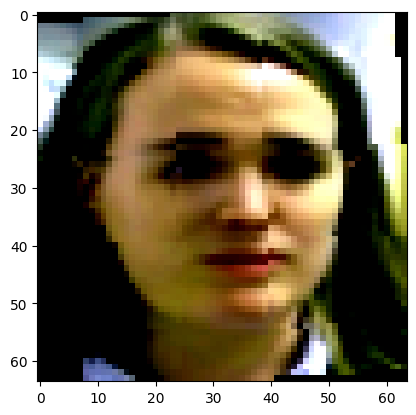

In [ ]:
import matplotlib.pyplot as plt

def imshow(img):
    img = img / 2 + 0.5   # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

imshow(images[5])


## 4. Build the Model

In [19]:
import torch
import torch.nn as nn
import timm

class CNN_ViT_BiLSTM(nn.Module):
    def __init__(self, cnn_model='efficientnet_b0', vit_model='vit_base_patch16_224', lstm_hidden=256, lstm_layers=1):
        super(CNN_ViT_BiLSTM, self).__init__()

        # CNN backbone (pretrained)
        self.cnn = timm.create_model(cnn_model, pretrained=True)
        self.cnn.reset_classifier(0)  # remove classifier to get features
        cnn_feature_dim = self.cnn.num_features

        # Freeze CNN
        for param in self.cnn.parameters():
            param.requires_grad = False

        # ViT backbone (pretrained)
        self.vit = timm.create_model(vit_model, pretrained=True)
        self.vit.reset_classifier(0)
        vit_feature_dim = self.vit.num_features

         # Freeze ViT
        for param in self.vit.parameters():
            param.requires_grad = False

        # BiLSTM for temporal modeling
        self.lstm = nn.LSTM(
            input_size=cnn_feature_dim + vit_feature_dim, # Corrected input size
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True
        )


        # Fully connected layer for binary output
        self.fc = nn.Sequential(
            nn.Linear(lstm_hidden*2, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        """
        x: shape (B, T, C, H, W)
        B = batch size, T = number of frames per video
        """
        B, T, C, H, W = x.shape
        x_flat = x.view(B*T, C, H, W) # Flatten B and T dimensions for CNN and ViT processing

        # CNN feature extraction from original images
        cnn_raw_feat = self.cnn.forward_features(x_flat)
        # Apply global pooling and flatten for CNN
        cnn_feat = self.cnn.global_pool(cnn_raw_feat).flatten(1)

        # ViT feature extraction from original images (parallel processing)
        vit_raw_feat = self.vit.forward_features(x_flat)
        # Extract CLS token for ViT
        vit_feat = vit_raw_feat[:, 0]

        # Concatenate features
        combined_feat = torch.cat((cnn_feat, vit_feat), dim=1) # Combine features

        # Reshape to sequence for LSTM
        seq_feat = combined_feat.view(B, T, -1)

        # BiLSTM
        lstm_out, _ = self.lstm(seq_feat)  # lstm_out: (B, T, 2*hidden)
        lstm_last = lstm_out[:, -1, :]     # take last frame output

        # FC layer
        out = self.fc(lstm_last)
        return out

In [20]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CNN_ViT_BiLSTM().to(device)

In [ ]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

## 5. Loop and Fit the Model

In [ ]:
param_grid = {
    "lr": [1e-3, 5e-4, 1e-4],
    "batch_size": [8, 16, 32],
    "lstm_hidden": [128, 256, 512]
}


In [ ]:
def train_model(lr, batch_size, lstm_hidden):

    model = CNN_ViT_BiLSTM(lstm_hidden=lstm_hidden).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')

    for epoch in range(5):  # fewer epochs for grid search
        model.train()

        train_loss = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            images = images.unsqueeze(1)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.float().unsqueeze(1).to(device)

                images = images.unsqueeze(1)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_loss += loss.item()

        val_loss = val_loss / len(val_loader)

        if val_loss < best_val_loss:
            best_val_loss = val_loss

    return best_val_loss


In [ ]:
from itertools import product

results = []

for lr, batch_size, lstm_hidden in product(
        param_grid["lr"],
        param_grid["batch_size"],
        param_grid["lstm_hidden"]):

    print(f"\nTesting lr={lr}, batch_size={batch_size}, lstm_hidden={lstm_hidden}")

    val_loss = train_model(lr, batch_size, lstm_hidden)

    results.append({
        "lr": lr,
        "batch_size": batch_size,
        "lstm_hidden": lstm_hidden,
        "val_loss": val_loss
    })

    print(f"Validation loss: {val_loss}")


Testing lr=0.001, batch_size=8, lstm_hidden=128
Validation loss: 0.6021748620920464

Testing lr=0.001, batch_size=8, lstm_hidden=256
Validation loss: 0.6168070553662541

Testing lr=0.001, batch_size=8, lstm_hidden=512
Validation loss: 0.6280508793978551

Testing lr=0.001, batch_size=16, lstm_hidden=128
Validation loss: 0.7202556391317297

Testing lr=0.001, batch_size=16, lstm_hidden=256
Validation loss: 0.7290915529158545

Testing lr=0.001, batch_size=16, lstm_hidden=512
Validation loss: 0.7815121492996565

Testing lr=0.001, batch_size=32, lstm_hidden=128
Validation loss: 0.6296257643245293

Testing lr=0.001, batch_size=32, lstm_hidden=256
Validation loss: 0.6676557238309844

Testing lr=0.001, batch_size=32, lstm_hidden=512
Validation loss: 0.7193683020640427

Testing lr=0.0005, batch_size=8, lstm_hidden=128


In [ ]:
best_result = min(results, key=lambda x: x["val_loss"])

print("\nBest Hyperparameters:")
print(best_result)

In [ ]:
from tqdm import tqdm
import os
import torch
import matplotlib.pyplot as plt

# Paths
checkpoint_path = "/content/drive/MyDrive/copy_checkpoint.pth"
best_model_path = "/content/drive/MyDrive/copy_best_model.pth"

# Early stopping settings
patience = 3
counter = 0
best_val_loss = float('inf')

start_epoch = 0

# Initialize metric lists
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Resume if checkpoint exists
if os.path.exists(checkpoint_path):
    print("Loading checkpoint...")
    checkpoint = torch.load(checkpoint_path)

    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    start_epoch = checkpoint['epoch'] + 1
    best_val_loss = checkpoint.get('best_val_loss', float('inf'))
    counter = checkpoint.get('counter', 0)

    # LOAD METRICS (IMPORTANT)
    train_losses = checkpoint.get('train_losses', [])
    val_losses = checkpoint.get('val_losses', [])
    train_accuracies = checkpoint.get('train_accuracies', [])
    val_accuracies = checkpoint.get('val_accuracies', [])

    print(f"Resuming from epoch {start_epoch}")

epochs = 25

for epoch in range(start_epoch, epochs):
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in tqdm(train_loader):
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        images = images.unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).int()

        train_correct += (preds == labels.int()).sum().item()
        train_total += labels.size(0)

    train_acc = train_correct / train_total
    train_loss = train_loss / len(train_loader)

    # Validation
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            images = images.unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).int()

            correct += (preds == labels.int()).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    val_loss = val_loss / len(val_loader)

    print(f"Epoch {epoch+1}: "
          f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, "
          f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

    # SAVE METRICS
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Check for improvement
    if val_loss < best_val_loss:
        print("✅ Validation improved — saving best model")

        best_val_loss = val_loss
        counter = 0

        torch.save(model.state_dict(), best_model_path)
    else:
        counter += 1
        print(f"⚠️ No improvement ({counter}/{patience})")

    # Save checkpoint (WITH METRICS)
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'best_val_loss': best_val_loss,
        'counter': counter,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies
    }, checkpoint_path)

    # Early stopping
    if counter >= patience:
        print("⛔ Early stopping triggered")
        break

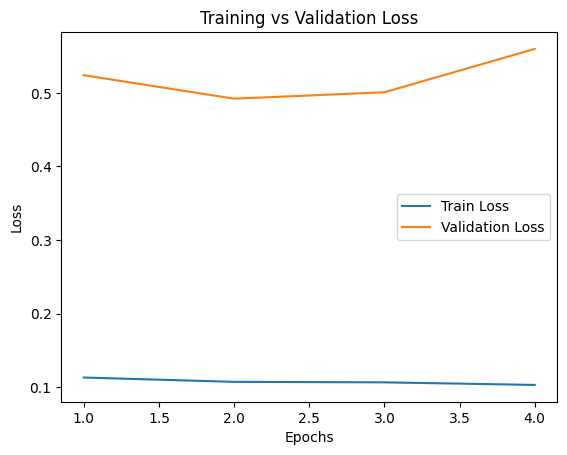

In [ ]:
# =========================
# 📊 PLOT AFTER TRAINING
# =========================

epochs_range = range(1, len(train_losses) + 1)

# Loss plot
plt.figure()
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
# plt.savefig("/content/drive/MyDrive/XST-Deepfake-Detection/Model/loss_curve.png")
plt.show()

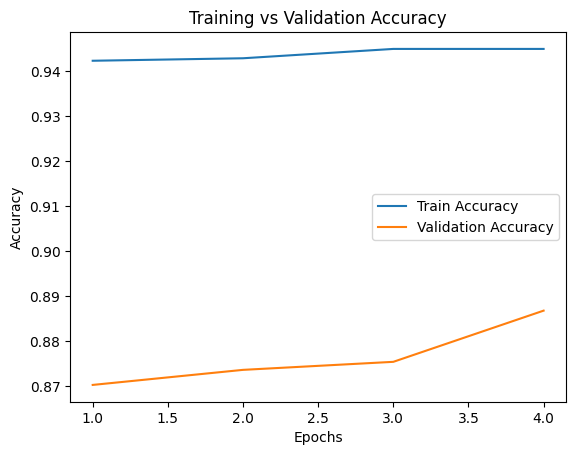

In [ ]:
# Accuracy plot
plt.figure()
plt.plot(epochs_range, train_accuracies, label='Train Accuracy')
plt.plot(epochs_range, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
# plt.savefig("/content/drive/MyDrive/XST-Deepfake-Detection/Model/accuracy_curve.png")
plt.show()

## 6. Make Prediction

In [ ]:
from PIL import Image

def predict_image(model, image_path, device):
    model.eval()

    transform = transforms.Compose([
        transforms.Resize((224, 224)), # Changed to match training size
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).unsqueeze(1).to(device) # Add T dimension (T=1 for single image)

    with torch.no_grad():
        output = model(image)
        prob = torch.sigmoid(output)
        pred = (prob > 0.5).int()

    return pred.item(), prob.item()

In [ ]:
classes = val_dataset.classes
url = "/content/processed_ffpp/content/processed_ffpp/val/real/01__talking_angry_couch/0000.jpg"
label, prob = predict_image(model, url, device)

print(f"Prediction: {classes[label]} ({prob:.2f})")

Prediction: real (0.78)


## 7. Evaluate the Model

In [ ]:
import torch

def test_model(model, test_loader, device):
    model.eval()  # evaluation mode
    correct = 0
    total = 0
    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():  # no gradients
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)  # shape (B,1)

            # Add T dimension (T=1 for single image) to match model's expected input
            images = images.unsqueeze(1)

            outputs = model(images)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).int()

            correct += (preds == labels.int()).sum().item()
            total += labels.size(0)

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total
    print(f"Test Accuracy: {accuracy:.4f}")

    return all_preds, all_labels, all_probs

In [ ]:
all_preds, all_labels, all_probs = test_model(model, test_loader, device)

Test Accuracy: 0.8518


              precision    recall  f1-score   support

        fake       0.84      0.85      0.85      2433
        real       0.87      0.85      0.86      2669

    accuracy                           0.85      5102
   macro avg       0.85      0.85      0.85      5102
weighted avg       0.85      0.85      0.85      5102

Confusion Matrix:
 [[2080  353]
 [ 403 2266]]


<Figure size 640x480 with 0 Axes>

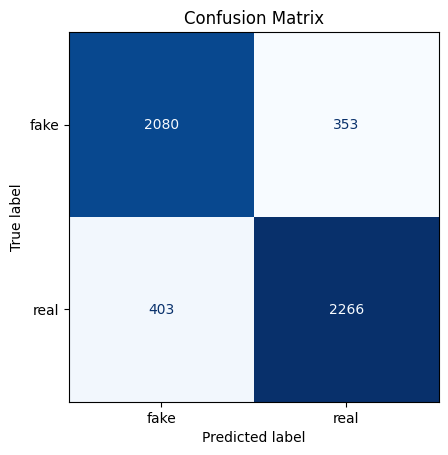

AUC: 0.9288307687616739


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Get unique labels present
unique_labels = np.unique(all_labels).astype(int)
present_target_names = [classes[l] for l in unique_labels]

# 📊 Classification report
print(classification_report(
    all_labels,
    all_preds,
    labels=unique_labels,
    target_names=present_target_names
))

# Confusion matrix (raw values)
cm = confusion_matrix(all_labels, all_preds, labels=unique_labels)
print("Confusion Matrix:\n", cm)

# Confusion Matrix Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=present_target_names)

plt.figure()
disp.plot(cmap='Blues', colorbar=False)
plt.title("Confusion Matrix")

# Save to Drive (optional)
#plt.savefig("/content/drive/MyDrive/XST-Deepfake-Detection/Model/confusion_matrix.png")

plt.show()

# AUC score
print("AUC:", roc_auc_score(all_labels, all_probs))

## 8. Save the Model

In [ ]:
model.load_state_dict(torch.load(best_model_path))
model.eval()

CNN_ViT_BiLSTM(
  (cnn): EfficientNet(
    (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNormAct2d(
      32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (blocks): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn1): BatchNormAct2d(
            32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (conv_pw): Con

### Model Architecture: CNN_ViT_BiLSTM

This model is a hybrid architecture designed to combine the strengths of Convolutional Neural Networks (CNNs), Vision Transformers (ViTs), and Bidirectional Long Short-Term Memory (BiLSTM) networks for video frame analysis.

Here's a breakdown of its components and data flow:

1.  **Input:** The model expects input `x` of shape `(B, T, C, H, W)` where:
    *   `B`: Batch size
    *   `T`: Number of frames (time steps) per video
    *   `C`: Number of channels (e.g., 3 for RGB images)
    *   `H`: Height of the image
    *   `W`: Width of the image

2.  **Feature Extraction (Parallel):**
    *   For each frame, the `(B*T, C, H, W)` flattened input is simultaneously passed through two separate, pre-trained feature extractors:
        *   **CNN Backbone (EfficientNet_b0):** A pre-trained EfficientNet-B0 model is used. Its classifier head is removed, and it extracts rich spatial features from each image. These features are then globally pooled and flattened.
        *   **ViT Backbone (ViT_base_patch16_224):** A pre-trained Vision Transformer base model is also used. Its classifier head is removed, and it extracts sequence-aware features, typically taking the `[CLS]` token's output as the main feature representation.
    *   Both CNN and ViT backbones are frozen, meaning their weights are not updated during training, leveraging their powerful pre-learned representations.

3.  **Feature Concatenation:**
    *   The features extracted by the CNN and ViT for each frame are concatenated (`torch.cat`) into a single feature vector. This combined vector represents a richer description of each individual frame.

4.  **Temporal Modeling (BiLSTM):**
    *   The sequence of combined feature vectors (one for each frame in the video) is then reshaped back into `(B, T, combined_feature_dim)`.
    *   This sequence is fed into a **Bidirectional LSTM** layer. The BiLSTM processes the sequence of frame features, capturing temporal dependencies and relationships between frames in both forward and backward directions.
    *   Only the output from the last time step (`lstm_last`) of the BiLSTM is taken for the final prediction. This output effectively summarizes the information across the entire video sequence.

5.  **Classification Head:**
    *   A simple Fully Connected (FC) layer, followed by ReLU activation and Dropout, processes the BiLSTM's final output.
    *   The final output layer is a single linear unit, providing a single scalar output that is then typically passed through a sigmoid activation (outside the model for `BCEWithLogitsLoss`) for binary classification.

In [ ]:
# Install torchinfo to get a detailed model summary
!pip install torchinfo

In [ ]:
from torchinfo import summary

# Assuming 'model' is your CNN_ViT_BiLSTM model instance
# Provide a sample input size that matches (B, T, C, H, W)
# For a single image, T=1
summary(model, input_size=(1, 1, 3, 224, 224), device=device)

Layer (type:depth-idx)                             Output Shape              Param #
CNN_ViT_BiLSTM                                     [1, 1]                    --
├─EfficientNet: 1-1                                --                        --
│    └─Conv2d: 2-1                                 [1, 32, 112, 112]         (864)
│    └─BatchNormAct2d: 2-2                         [1, 32, 112, 112]         64
│    │    └─Identity: 3-1                          [1, 32, 112, 112]         --
│    │    └─SiLU: 3-2                              [1, 32, 112, 112]         --
│    └─Sequential: 2-3                             [1, 320, 7, 7]            --
│    │    └─Sequential: 3-3                        [1, 16, 112, 112]         (1,448)
│    │    └─Sequential: 3-4                        [1, 24, 56, 56]           (16,714)
│    │    └─Sequential: 3-5                        [1, 40, 28, 28]           (46,640)
│    │    └─Sequential: 3-6                        [1, 80, 14, 14]           (242,930)
│    │  

In [ ]:
total_params = 0
trainable_params = 0
non_trainable_params = 0

for name, parameter in model.named_parameters():
    param_count = parameter.numel()
    total_params += param_count
    if parameter.requires_grad:
        trainable_params += param_count
    else:
        non_trainable_params += param_count

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Non-trainable parameters: {non_trainable_params:,}")

Total parameters: 94,594,685
Trainable parameters: 4,788,481
Non-trainable parameters: 89,806,204
